# Homework 1

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1. Understanding round-off error

Consider a quadratic equation of the form $ax^{2} + bx + c = 0$. The two solutions are:

$
x= \dfrac{-b \pm \sqrt{b^2 - 4ac}}{2a}
$

This expression may be problematic with respect to round-off errors if $b\gg a,c$ because then $\sqrt{b^2-4ac}\approx \sqrt{b} = |b|$.

Let's recall that round-off errors often occur when subtracting close large numbers so the problem becomes significant for the root with different signs in the numerator. Instead we can calculate this root as,

$x_1= \dfrac{-b+\sqrt{b^2 - 4ac}}{2a} = \dfrac{(-b+\sqrt{b^2 - 4ac})(-b-\sqrt{b^2 - 4ac})}{2a(-b-\sqrt{b^2 - 4ac})} = \dfrac{2c}{-b-\sqrt{b^2 - 4ac}}$ for $b>0$

$x_1= \dfrac{-b-\sqrt{b^2 - 4ac}}{2a} = \dfrac{(-b-\sqrt{b^2 - 4ac})(-b+\sqrt{b^2 - 4ac})}{2a(-b+\sqrt{b^2 - 4ac})} = \dfrac{2c}{-b+\sqrt{b^2 - 4ac}}$ for $b<0$

### Problem 2. Round-off error and accurate calculation of the exponential series 

We define the n-th partial sum of the exponential series as:

$
e^x \simeq S_n(x)= 1 + \dfrac{x}{1!} + \dfrac{x^2}{2!} + \dfrac{x^3}{3!} + ... + \dfrac{x^n}{n!}
$

In [6]:
#Series expansion for given number of terms n
def exp_series(x,n):
    partial_sum = 0
    for i in range(0,n+1):
        partial_sum += (x**i)/(math.factorial(i))
    return partial_sum

#Error of the series expansion 
def epsilon_n(x,n):
    error = abs(np.exp(x)-exp_series(x,n))/abs(np.exp(x))
    return error

x=20
n=100

print('The nth partial sum is:', exp_series(x,n))
print('The theoretical value is:', np.exp(x))
print('The relative error is:', epsilon_n(x,n))

The nth partial sum is: 485165195.40979016
The theoretical value is: 485165195.4097903
The relative error is: 2.457086589859197e-16


<>:9: SyntaxWarning: invalid escape sequence '\q'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\q'
<>:17: SyntaxWarning: invalid escape sequence '\e'
<>:9: SyntaxWarning: invalid escape sequence '\q'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\q'
<>:17: SyntaxWarning: invalid escape sequence '\e'
/var/folders/r3/x1_dzkd17bl79jcx6v49vh600000gr/T/ipykernel_90437/1643685407.py:9: SyntaxWarning: invalid escape sequence '\q'
  ax1.set_title('$Error\quad for \quad e^{20}$')
/var/folders/r3/x1_dzkd17bl79jcx6v49vh600000gr/T/ipykernel_90437/1643685407.py:11: SyntaxWarning: invalid escape sequence '\e'
  ax1.set_ylabel('$\epsilon_n$')
/var/folders/r3/x1_dzkd17bl79jcx6v49vh600000gr/T/ipykernel_90437/1643685407.py:15: SyntaxWarning: invalid escape sequence '\q'
  ax2.set_title('$Error\quad for \quad e^{-20}$')
/var/folders/r3/x1_dzkd17bl79jcx6v49vh600000gr/T/ipykernel_90437/1643685407.py:17:

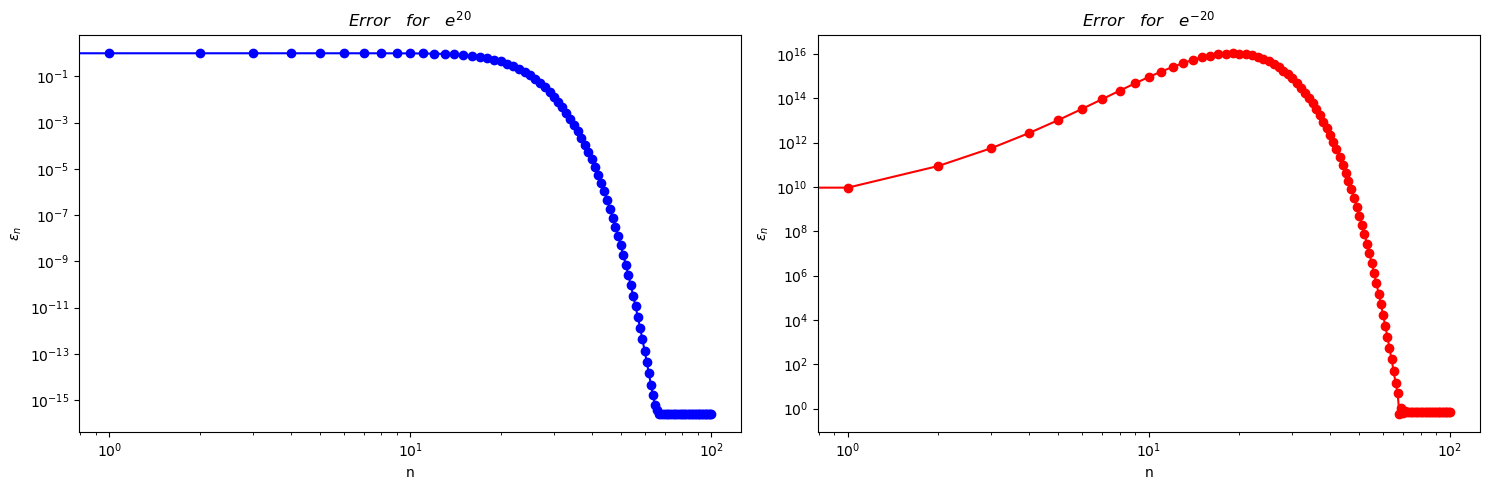

In [7]:
#Let's plot the error as n scales from 0 to 100, for x = +20,-20 
n_values = list(range(0,101))
epsilon_values_pos = [epsilon_n(20,n) for n in n_values]
epsilon_values_neg = [epsilon_n(-20,n) for n in n_values]

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(15,5))
#Plot_1:+x
ax1.loglog(n_values, epsilon_values_pos, marker='o', linestyle='-', color='blue')
ax1.set_title('$Error\quad for \quad e^{20}$')
ax1.set_xlabel('n')
ax1.set_ylabel('$\epsilon_n$')

#Plot_2:-x
ax2.loglog(n_values, epsilon_values_neg, marker='o', linestyle='-', color='red')
ax2.set_title('$Error\quad for \quad e^{-20}$')
ax2.set_xlabel('n')
ax2.set_ylabel('$\epsilon_n$')

plt.tight_layout()
plt.show()

From the plots above we can see that for the positive exponent $(x=20)$ the relative error decreases steadily up until $n\lesssim 20$ where it decreases quickly settling into a value lesser than $10^{-15}$ for larger values of $n$. 

In contrast, the relative error for the negative exponent blows up for $n \approx 20$  (probably because the series is alternating and there is significant round-off error) before decaying quickly and settling as $n$ approaches $10^2$. 

To get a better approximation for the negative exponent let's use the trivial equality,

$e^{-x}=(e^{-1})^{x}=\dfrac{1}{e^x}$

Then, 

$
e^{-x} \simeq \dfrac{1}{S_n(x)}= \dfrac{1}{1 + \dfrac{x}{1!} + \dfrac{x^2}{2!} + \dfrac{x^3}{3!} + ... + \dfrac{x^n}{n!}}
$

<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
/var/folders/r3/x1_dzkd17bl79jcx6v49vh600000gr/T/ipykernel_90437/1690061030.py:19: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('$\epsilon_n$')


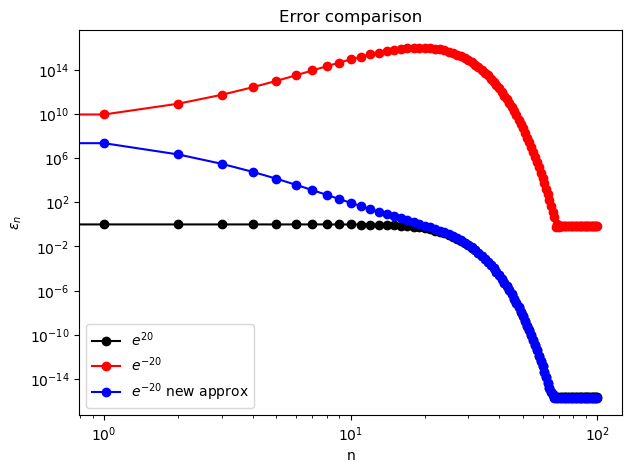

In [9]:
#Let's try it
def exp_series_neg(x,n):
    partial_sum = 0
    for i in range(0,n+1):
        partial_sum += (x**i)/(math.factorial(i))
    return 1/partial_sum

def epsilon_new(x,n):
    error = abs(np.exp(-x)-exp_series_neg(x,n))/np.exp(-x)
    return error

epsilon_values_neg_new = [epsilon_new(20,n) for n in n_values]
plt.figure(figsize=(7, 5))

plt.loglog(n_values, epsilon_values_pos, marker='o', color = 'black',label='$e^{20}$')
plt.loglog(n_values, epsilon_values_neg, marker='o', color = 'red', label='$e^{-20}$')
plt.loglog(n_values, epsilon_values_neg_new, marker='o', color = 'blue', label='$e^{-20}$ new approx')

plt.ylabel('$\epsilon_n$')
plt.xlabel('n')
plt.title('Error comparison')
plt.legend()

plt.show()

### Problem 3. Errors in numerical differentiation

Let's calculate the derivative of the function  $f(x) = sin(x)$ at the point $x = \pi/4$ using the first-order forward difference:

$f'(x_i) = \dfrac{f_{i+1}-f_i}{\Delta x}$ where $f_i=f(x_i)$ and $f_{i+1}=f(x_i+\Delta x)$

We are also going to calculate the second-order central difference,

$f'(x_i) = \dfrac{f_{i+1}-f_{i+1}} {2 \Delta x}$ where $f_{i-1}=f(x_i-\Delta x)$ 

And the fourth-order central difference,

$f'(x_i) = \dfrac{-f_{i+2}+8f_{i+1}-8f_{i-1}+f_{i-2}} {12 \Delta x}$ where $f_{i\pm 2}=f(x_i \pm 2\Delta x)$ 


The theoretical value is: 0.7071067811865476
The first-order forward derivative of sin(x) at x=pi/4 is: 0.7067531099743674
The second-order centered derivative of sin(x) at x=pi/4 is: 0.707106663335455
The fourth-order centered derivative of sin(x) at x=pi/4 is: 0.707106781186582


<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:49: SyntaxWarning: invalid escape sequence '\e'
<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:49: SyntaxWarning: invalid escape sequence '\e'
/var/folders/r3/x1_dzkd17bl79jcx6v49vh600000gr/T/ipykernel_90437/156567061.py:48: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_xlabel('$\Delta x$')
/var/folders/r3/x1_dzkd17bl79jcx6v49vh600000gr/T/ipykernel_90437/156567061.py:49: SyntaxWarning: invalid escape sequence '\e'
  ax1.set_ylabel('$\epsilon$')


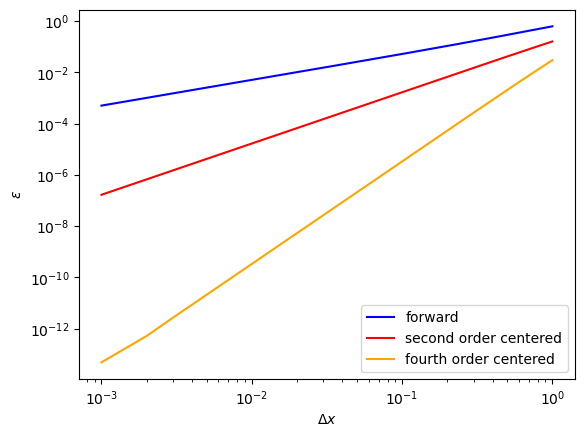

In [10]:
#First-order forward difference
def derivative_forward(x, delta):
    f_i = np.sin(x)
    f_i1 = np.sin(x+delta)
    derivative= (f_i1-f_i)/(delta)
    return derivative 
#Second-order centered difference
def derivative_second(x, delta):
    f_i_1 = np.sin(x-delta)
    f_i1 = np.sin(x+delta)
    derivative= (f_i1-f_i_1)/(2.0*delta)
    return derivative 
#Fourth-order centered difference
def derivative_fourth(x, delta):
    f_i_2 = np.sin(x-2.0*delta)
    f_i_1 = np.sin(x-delta)
    f_i1 = np.sin(x+delta)
    f_i2 = np.sin(x+2.0*delta)
    derivative= (-f_i2 + 8.0*f_i1 - 8.0*f_i_1 +f_i_2)/(12.0*delta)
    return derivative 

def epsilon_1(x,delta):
    error = abs(np.cos(x)-derivative_forward(x,delta))/np.cos(x)
    return error

def epsilon_2(x,delta):
    error = abs(np.cos(x)-derivative_second(x,delta))/np.cos(x)
    return error

def epsilon_4(x,delta):
    error = abs(np.cos(x)-derivative_fourth(x,delta))/np.cos(x)
    return error

print('The theoretical value is:', np.cos(np.pi/4))
print("The first-order forward derivative of sin(x) at x=pi/4 is:", derivative_forward(np.pi/4,0.001))
print("The second-order centered derivative of sin(x) at x=pi/4 is:", derivative_second(np.pi/4,0.001))
print("The fourth-order centered derivative of sin(x) at x=pi/4 is:", derivative_fourth(np.pi/4,0.001))

#Let's plot the errors
deltas=np.linspace(1e-3,1,1000)
epsilon_values_1 = [epsilon_1(np.pi/4,delta) for delta in deltas]
epsilon_values_2 = [epsilon_2(np.pi/4,delta) for delta in deltas]
epsilon_values_4 = [epsilon_4(np.pi/4,delta) for delta in deltas]
fig1,ax1=plt.subplots()
ax1.loglog(deltas,epsilon_values_1, color='blue', label='forward')
ax1.loglog(deltas,epsilon_values_2, color='red', label='second order centered')
ax1.loglog(deltas,epsilon_values_4, color='orange', label='fourth order centered')
ax1.set_xlabel('$\Delta x$')
ax1.set_ylabel('$\epsilon$')
plt.legend()
plt.show()

We can observe that for very small $\Delta x$ the relative errors are more spread. The fourth order centered derivative being the most accurate approximation, followed by the second order centered derivative and the first order forward difference. The slopes indicate the order of the error.

### Problem 4. Comparing methods of integration

Let's consider the function:

$I= \int_{0}^{1}sin^{2}(\sqrt{100x})\,dx$

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/var/folders/r3/x1_dzkd17bl79jcx6v49vh600000gr/T/ipykernel_90437/2696242748.py:6: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_ylabel('$sin^2(\sqrt{100x})$')


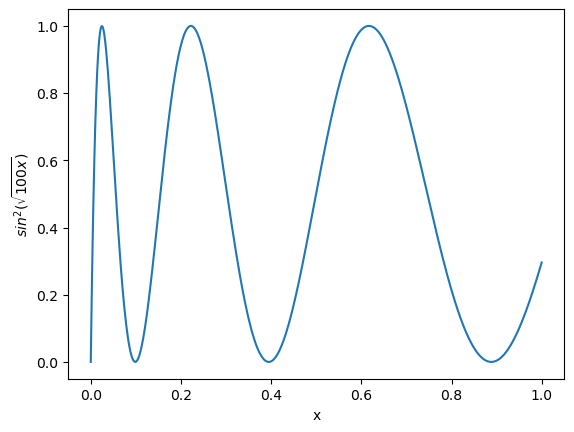

In [11]:
#Let's plot the integrand over the range of the integral
x=np.linspace(0,1,500)
fig1,ax1=plt.subplots()
ax1.plot(x,np.sin(np.sqrt(100.0*x))**2)
ax1.set_xlabel('x')
ax1.set_ylabel('$sin^2(\sqrt{100x})$')
plt.show()

### Adaptive Trapezoid 
Now let's use the adaptive trapezoid rule to calculate the integral to an approximate accuracy of $\epsilon = 10^{-6}$

In [12]:
#Trapezoid rule
def trapezoid(lim_inf, lim_sup, subints):
    a = lim_inf
    b = lim_sup
    dx = (b-a)/subints 
    x_i = a
    x_f = a+dx
    integral =0.0
    for i in range(subints):
        integral += dx*(np.sin(np.sqrt(100.0*x_i))**2.0 + np.sin(np.sqrt(100.0*x_f))**2.0)/2.0
        x_i += dx
        x_f += dx
    return integral 

lim_inf = 0.0
lim_sup = 1.0
n_subints = 1
I_1 = trapezoid(lim_inf, lim_sup, n_subints)

#print('For 1 subinterval the integral is', I_1)

#Now let's calculate the integral to an approximate accuracy of 10^-6
eps = 1e-6

while True:
    n_subints *= 2
    dx = (lim_sup - lim_inf) / n_subints
        
    total_sum = 0.0
    for k in range(1, n_subints, 2):
        total_sum += np.sin(np.sqrt(100.0 * (lim_inf + k * dx)))**2.0

    I_i = 0.5 * I_1 + dx * total_sum
    error = abs((I_i - I_1) / 3.0)
    
    if error < eps:
        print('For', n_subints, 'subintervals the integral is', I_i)
        print('And the error is', error)
        break
        
    I_1 = I_i

For 4096 subintervals the integral is 0.455832058278271
And the error is 4.74025541467397e-07


### Romberg Integration

Now let's use the Romberg integration to solve the integral, also to an approximate accuracy of $\epsilon = 10^{-6}$

In [13]:
#Romberg inttegration
def romberg(lim_inf, lim_sup, eps):
    n_subints = 1 
    I_1 = trapezoid(lim_inf, lim_sup, n_subints) #Step i = 1
    romberg_prev = [I_1]         
    
    while True:
        n_subints *= 2
        dx = (lim_sup - lim_inf) / n_subints
        total_sum = 0.0
        
        #Trapezoid rule
        for k in range(1, n_subints, 2):
            total_sum += np.sin(np.sqrt(100.0 * (lim_inf + k * dx)))**2.0
        I_i = 0.5 * romberg_prev[0] + dx * total_sum   #R_{i,m=1} = I_i, first run calculates R_{2,1}

        #For each step i we need to calculate a row: R_{i,2}, R_{i,3}, ..., R_{i,m=i}, in total i-1 terms
        r_row = [I_i]
        for m in range(2, len(romberg_prev) + 2):   #m=2,..,i  
            r_row.append(r_row[m-2] + (r_row[m-2] - romberg_prev[m-2])/((4**(m-1))- 1.0)) # [m-2] because we start at [0]

        #We need to estimate the error for m=i
        err = abs(r_row[-1] - romberg_prev[-1])

        if err < eps:
            print('For', n_subints, 'subintervals the integral is', r_row[-1])
            print('And the error is', err)
            break

        romberg_prev = r_row
    
romberg(lim_inf, lim_sup, eps)

For 128 subintervals the integral is 0.4558325323050135
And the error is 3.784363489245379e-08


We can observe that there was significant improvement with respect to the adaptive trapezoid rule since the the number of subintervals was drastically reduced and the accuracy increased.

### Gauss-Legendre Approach

Let's use the Gauss-Legendre approach to calculate the integral. 

We will map the interval of integration $x \in [0,1]$ to $z \in [-1,1]$ by using the change of variables,

$x = \dfrac{b+a}{2} + \dfrac{(b-a)z}{2} = \dfrac{1}{2} + \dfrac{z}{2}$

so that, 

$\int_{0}^{1}f(x)\,dx \simeq \dfrac{1}{2 }\sum_{i=1}^{n}w_i f(\dfrac{1}{2} + \dfrac{x_i}{2})$

with $f(x)= sin^{2}(\sqrt{100x})$ and $x_i, w_i$ being the quadrature weights and abscissae as tabulated in https://pomax.github.io/bezierinfo/legendre-gauss.html

To check the accuracy we can calculate the exact value of the integral,

$
\int_{0}^{1}sin^{2}(\sqrt{100x})\,dx = \dfrac{1}{2} \int_{0}^{1}1-cos(20\sqrt{x})\,dx= \dfrac{1}{400}(201-20sin(20)-cos(20))
$

In [14]:
#Table of points and weights
points_and_weights = {
    2: (np.array([-0.5773502691896257,  0.5773502691896257]),
        np.array([1.0000000000000000,1.0000000000000000])),
    
    3: (np.array([-0.7745966692414834, 0.0000000000000000, 0.7745966692414834]),
        np.array([0.5555555555555556, 0.8888888888888888, 0.5555555555555556])),
    
    4: (np.array([-0.3399810435848563, 0.3399810435848563,-0.8611363115940526,-0.8611363115940526]),
        np.array([0.6521451548625461,0.6521451548625461, 0.3478548451374538,0.3478548451374538])),
    
    5: (np.array([0.0000000000000000,-0.5384693101056831,0.5384693101056831,-0.9061798459386640,0.9061798459386640]),
        np.array([0.5688888888888889,0.4786286704993665,0.4786286704993665,0.236926885056189,0.236926885056189])),
    
    6: (np.array([-0.6612093864662645,0.6612093864662645,-0.2386191860831969,0.2386191860831969,-0.9324695142031521,0.9324695142031521]), 
        np.array([0.3607615730481386,0.3607615730481386,0.4679139345726910,0.4679139345726910,0.1713244923791704,0.1713244923791704])),
    
    7: (np.array([0.0000000000000000,0.4058451513773972,-0.4058451513773972,-0.7415311855993945,0.7415311855993945, -0.9491079123427585, 0.9491079123427585]), 
        np.array([0.4179591836734694, 0.3818300505051189,0.3818300505051189,0.2797053914892766,0.2797053914892766,0.1294849661688697,0.1294849661688697])),
    
    8: (np.array([-0.1834346424956498,0.1834346424956498,-0.5255324099163290,0.5255324099163290,-0.7966664774136267,0.7966664774136267,-0.9602898564975363,0.9602898564975363]), 
        np.array([0.3626837833783620,0.3626837833783620,0.3137066458778873,0.3137066458778873,0.2223810344533745,0.2223810344533745,0.1012285362903763,0.1012285362903763])),
    
    9: (np.array([0.0000000000000000,-0.8360311073266358,0.8360311073266358,-0.9681602395076261,0.9681602395076261,-0.3242534234038089,0.3242534234038089,-0.6133714327005904,0.6133714327005904]), 
        np.array([0.3302393550012598,0.1806481606948574,0.1806481606948574,0.0812743883615744,0.0812743883615744,0.3123470770400029,0.3123470770400029,0.2606106964029354,0.2606106964029354])),
    
    10: (np.array([-0.1488743389816312,0.1488743389816312,-0.4333953941292472,0.4333953941292472,-0.6794095682990244,0.6794095682990244,-0.8650633666889845,0.8650633666889845,-0.9739065285171717,0.9739065285171717]), 
         np.array([0.2955242247147529,0.2955242247147529,0.2692667193099963,0.2692667193099963,0.2190863625159820,0.2190863625159820,0.1494513491505806,0.1494513491505806,0.0666713443086881,0.0666713443086881])),
}

#Gauss-Legendre approach 
def gauss_leg_approach(n):
    points, weights = points_and_weights[n]
    summ = 0.0
    for p, w in zip(points, weights):   
        x = 0.5 + (p/2.0)
        summ += w * np.sin(np.sqrt(100.0 * x))**2.0
    return 0.5 * summ

#To check accuracy let's calculate the exact integral
def exact_integral():
    integral = (1/400)*(201-(20*np.sin(20))-np.cos(20))
    return integral

print('The exact integral is', exact_integral())

#Loop over the number of points
for n in sorted(points_and_weights.keys()):
    I_n = gauss_leg_approach(n)
    error = abs(exact_integral()-I_n)
    if error < eps:
        print('For', n, 'points, the integral is:', I_n)
        print('And the error is', error)
        break


The exact integral is 0.4558325323090851
For 9 points, the integral is: 0.45583265544354196
And the error is 1.231344568530801e-07


### Problem 5. Integration to infinity

Let's consider the gamma function,

$\Gamma (a) = \int_{0}^{\infty} x^{a-1} e^{-x} \,dx = \int_{0}^{\infty}\phi(x) \,dx$ for $a>1$

<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
/var/folders/r3/x1_dzkd17bl79jcx6v49vh600000gr/T/ipykernel_90437/4239080209.py:8: SyntaxWarning: invalid escape sequence '\p'
  ax1.set_ylabel('$\phi(x)$')


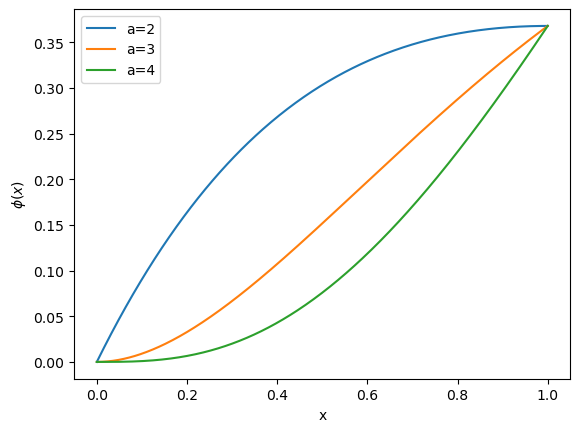

In [15]:
#Let's plot the integrand for a = 2,3,4
x=np.linspace(0,1,500)
fig1,ax1=plt.subplots()
ax1.plot(x,x**(2-1)*np.exp(-x), label= 'a=2')
ax1.plot(x,x**(3-1)*np.exp(-x), label= 'a=3')
ax1.plot(x,x**(4-1)*np.exp(-x), label= 'a=4')
ax1.set_xlabel('x')
ax1.set_ylabel('$\phi(x)$')
plt.legend()
plt.show()

The integrand $\phi(x)$ has a maximum where,

$\dfrac{d}{dx}\phi(x) = e^{-x} ((a-1)x^{a-2}-x^{a-1})= 0$ and $\dfrac{d^2}{dx^2}\phi(x)<0$, i.e when $x=a-1$

We will map the interval of integration $x \in [0,\infty)$ to $z \in [0,1]$ by using the change of variables,

$z = \dfrac{x}{x+c} \implies x = \dfrac{cz}{1-z} \implies dx = \dfrac{c}{(1-z)^2}\,dz$

Then the peak of the integrand $x = \dfrac{cz}{1-z} = a-1$, by setting $z=\dfrac{1}{2}$, gives us that $c=a-1$

In terms of z, the integral is,

$\Gamma(a)= c^{a}\int_{0}^{1}\dfrac{z^{a-1}}{(1-z)^{a+1}}\,\exp\left(-\frac{c z}{1-z}\right)\,dz$ 

Recognizing that $z^{a-1} = e^{(a-1)\ln z}$,

$\Gamma(a)= c^{a}\int_{0}^{1}\exp \left( (a-1)\ln z - \frac{cz}{1-z} - (a+1)\ln (1-z) \right) \,dz$


And by choosing $c=a-1$, the integral is, 

$\Gamma(a) = \int_{0}^{1}\exp \left( a \ln(a-1)+ (a-1)\ln z - \frac{(a-1)z}{1-z} - (a+1)\ln (1-z) \right) \,dz $

In [16]:
#For Gauss-Legendre approach 
def gauss_leg_approach_new(a,n):
    points, weights = points_and_weights[n]
    summ = 0.0
    for p, w in zip(points, weights):   
        z = 0.5 + (p/2.0) #because it's the same interval as before: [0,1]
        argument = a*np.log(a-1) + (a-1)*np.log(z) - (a+1)*np.log(1-z) - (a-1)*z/(1.0 - z)
        summ += w*np.exp(argument) 
    return 0.5 * summ

#Loop over a =2,3,4
for a in range(2,5):
    for n in sorted(points_and_weights.keys()):
        I_n = gauss_leg_approach_new(a,n)
        print('For a =', a, 'and', n, 'points', 'the integral is:', I_n)

For a = 2 and 2 points the integral is: 1.1652394832724213
For a = 2 and 3 points the integral is: 0.7590586435250946
For a = 2 and 4 points the integral is: 1.0446156090345566
For a = 2 and 5 points the integral is: 1.048922407497441
For a = 2 and 6 points the integral is: 0.9943175625309011
For a = 2 and 7 points the integral is: 0.9870653261407595
For a = 2 and 8 points the integral is: 0.9993112272948955
For a = 2 and 9 points the integral is: 1.0032770832948275
For a = 2 and 10 points the integral is: 1.0011017539541154
For a = 3 and 2 points the integral is: 0.985379682363537
For a = 3 and 3 points the integral is: 1.961663713476433
For a = 3 and 4 points the integral is: 2.244061795105811
For a = 3 and 5 points the integral is: 1.9022648091362038
For a = 3 and 6 points the integral is: 1.9850422768609624
For a = 3 and 7 points the integral is: 2.0241699797308734
For a = 3 and 8 points the integral is: 1.9985850514287364
For a = 3 and 9 points the integral is: 1.9950475834876114
